# **Listings dataset**

## 1. Import Data

In [ ]:
# Import libraries

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load Airbnb listings dataset
airbnb_proj = pd.read_csv(
    "Listings.csv",
    encoding="latin1",      # latin1 handles special characters in European cities (Paris, Rome, etc.)
    low_memory=False,       # low_memory=False avoids dtype guessing issues
    on_bad_lines="skip"     # skips corrupted rows instead of breaking
)

In [3]:
airbnb_proj.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

## 2. Detect and handle duplicates

In [4]:
dups_rows_listings = airbnb_proj.duplicated() #view the duplicated rows for listings file
dups_rows_listings

0         False
1         False
2         False
3         False
4         False
          ...  
279707    False
279708    False
279709    False
279710    False
279711    False
Length: 279712, dtype: bool

In [5]:
dups_rows_listings.sum()     #count the total number of duplicated rows

0

In [6]:
dup_col_listings = airbnb_proj.columns.duplicated()      #View the duplicated column
duplicate_columns_listings = airbnb_proj.columns[dup_col_listings]
print(duplicate_columns_listings)

Index([], dtype='object')


In [7]:
unique_value_counts_listings = airbnb_proj.nunique()     #count the number of unique value in each column
unique_value_counts_listings

listing_id                     279712
name                           265860
host_id                        182024
host_since                       4240
host_location                    7159
host_response_time                  4
host_response_rate                 91
host_acceptance_rate              101
host_is_superhost                   2
host_total_listings_count         206
host_has_profile_pic                2
host_identity_verified              2
neighbourhood                     660
district                            5
city                               10
latitude                       103503
longitude                      118021
property_type                     144
room_type                           4
accommodates                       17
bedrooms                           39
amenities                      245003
price                            5194
minimum_nights                    202
maximum_nights                    508
review_scores_rating               63
review_score

For reviews file

## 3. Detect and handle missing values

In [8]:
airbnb_proj.isnull().sum()      #View the number of rows with no data (missing value)

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [9]:
def missing(data):
  """
  For each attribute/column, count the number of missing entries.
  Return a list of all the coulmns with more than 10% missing entries.
  """
  missing_dict = dict()
  total = data.shape[0] # shape[0] is the number of rows
  for attribute in data.columns:
    missing = data[attribute].isna().sum() # count the number of Null/nan/na values
    frac = missing/total * 100 # as a percentage
    missing_dict[attribute] = frac
  return missing_dict

In [10]:
m_dict_listings = missing(airbnb_proj)
print ('\nMissing data in listings dataset\n')
m_dict_listings


Missing data in listings dataset



{'listing_id': 0.0,
 'name': 0.06256435190481639,
 'host_id': 0.0,
 'host_since': 0.058989246081684016,
 'host_location': 0.30030888914311865,
 'host_response_time': 46.04092781146322,
 'host_response_rate': 46.04092781146322,
 'host_acceptance_rate': 40.42979922205697,
 'host_is_superhost': 0.058989246081684016,
 'host_total_listings_count': 0.058989246081684016,
 'host_has_profile_pic': 0.058989246081684016,
 'host_identity_verified': 0.058989246081684016,
 'neighbourhood': 0.0,
 'district': 86.7678183274225,
 'city': 0.0,
 'latitude': 0.0,
 'longitude': 0.0,
 'property_type': 0.0,
 'room_type': 0.0,
 'accommodates': 0.0,
 'bedrooms': 10.523323990390116,
 'amenities': 0.0,
 'price': 0.0,
 'minimum_nights': 0.0,
 'maximum_nights': 0.0,
 'review_scores_rating': 32.67825477634138,
 'review_scores_accuracy': 32.78836803569386,
 'review_scores_cleanliness': 32.771207527742824,
 'review_scores_checkin': 32.80910364946802,
 'review_scores_communication': 32.77907276055371,
 'review_scores_l

In [11]:
cols_to_drop_listings = [ att for att,frac in m_dict_listings.items() if frac >70]
airbnb_proj.drop(columns=cols_to_drop_listings,
           inplace=True)

In [12]:
numerical_cols = [
    'bedrooms',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'host_total_listings_count',
    'host_since'
]

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


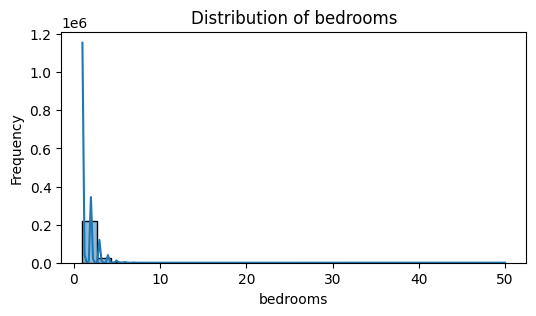

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


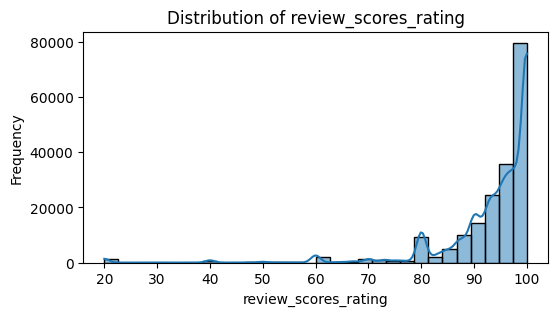

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


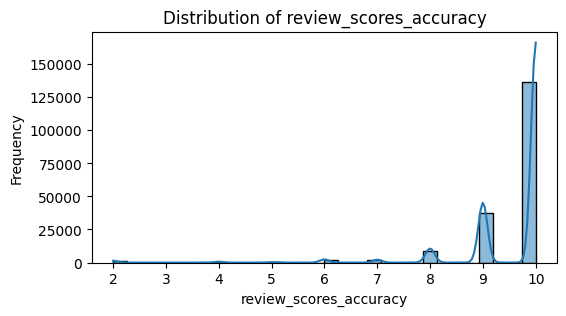

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


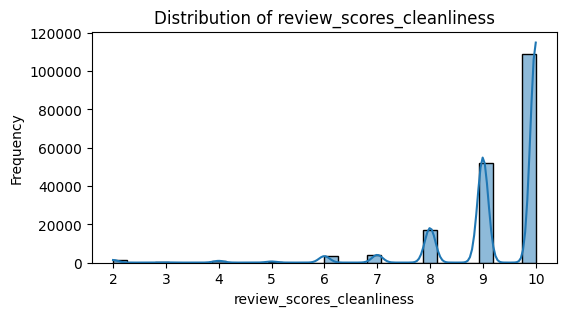

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


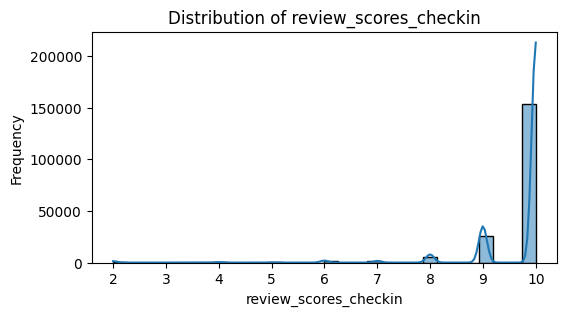

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


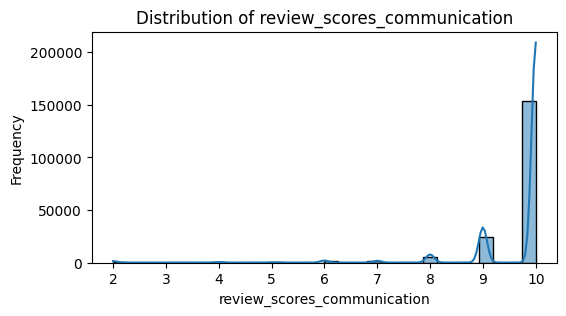

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


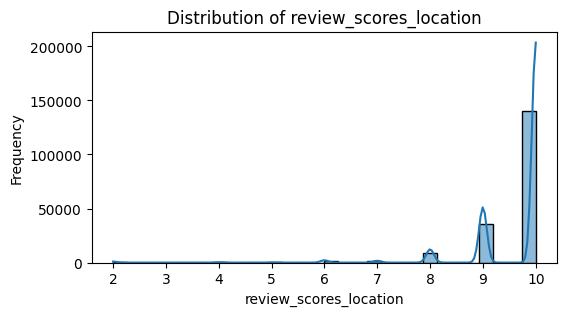

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


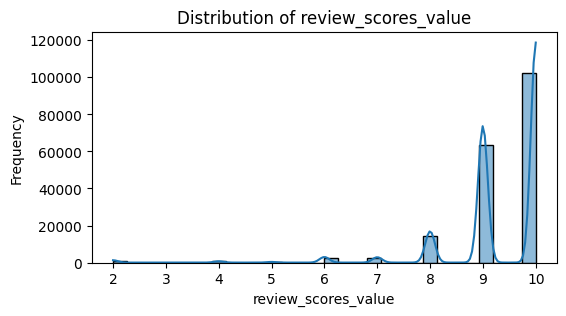

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


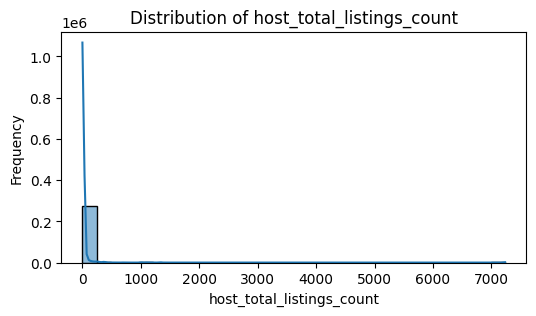

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


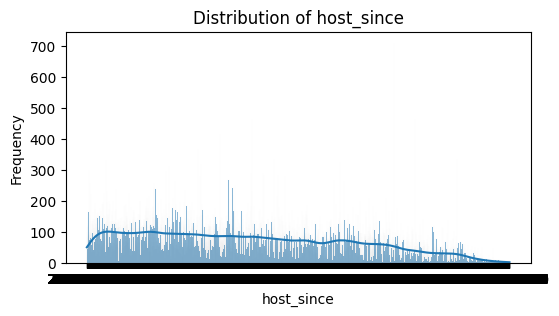

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(airbnb_proj[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [14]:
cols_listings = [
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified'
]                                                   #Missing values are treated as False

airbnb_proj[cols_listings] = airbnb_proj[cols_listings].fillna('f')

In [15]:
# Missing value will be filled by median (because it is less sensitive to extreme values.)

airbnb_proj['bedrooms'] = airbnb_proj['bedrooms'].fillna(airbnb_proj['bedrooms'].median())

airbnb_proj['review_scores_rating'] = airbnb_proj['review_scores_rating'].fillna(airbnb_proj['review_scores_rating'].median())

airbnb_proj['review_scores_accuracy'] = airbnb_proj['review_scores_accuracy'].fillna(airbnb_proj['review_scores_accuracy'].median())

airbnb_proj['review_scores_cleanliness'] = airbnb_proj['review_scores_cleanliness'].fillna(airbnb_proj['review_scores_cleanliness'].median())

airbnb_proj['review_scores_checkin'] = airbnb_proj['review_scores_checkin'].fillna(airbnb_proj['review_scores_checkin'].median())

airbnb_proj['review_scores_communication'] = airbnb_proj['review_scores_communication'].fillna(airbnb_proj['review_scores_communication'].median())

airbnb_proj['review_scores_location'] = airbnb_proj['review_scores_location'].fillna(airbnb_proj['review_scores_location'].median())

airbnb_proj['review_scores_value'] = airbnb_proj['review_scores_value'].fillna(airbnb_proj['review_scores_value'].median())

airbnb_proj['host_total_listings_count'] = airbnb_proj['host_total_listings_count'].fillna(airbnb_proj['host_total_listings_count'].median())

In [16]:
airbnb_proj['host_since'] = pd.to_datetime(
    airbnb_proj['host_since'],
    errors='coerce'
)

airbnb_proj['host_since'] = airbnb_proj['host_since'].fillna(
    airbnb_proj['host_since'].median()
)

In [17]:
#missing host_response_rate and host_acceptance_rate can also be understood that the host did not report. fill it with -1 to test the correlation
airbnb_proj['host_response_rate'] = airbnb_proj['host_response_rate'].fillna(-1)
airbnb_proj['host_acceptance_rate'] = airbnb_proj['host_acceptance_rate'].fillna(-1)

In [18]:
airbnb_proj['host_response_time'] = airbnb_proj['host_response_time'].fillna('Unknown')

In [19]:
airbnb_proj['host_location'] = airbnb_proj['host_location'].fillna(
    airbnb_proj.groupby('neighbourhood')['host_location'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
)

In [20]:
m_dict1_listings = missing(airbnb_proj) # missing value: 
print ('\nMissing data in train dataset\n')
m_dict1_listings


Missing data in train dataset



{'listing_id': 0.0,
 'name': 0.06256435190481639,
 'host_id': 0.0,
 'host_since': 0.0,
 'host_location': 0.0,
 'host_response_time': 0.0,
 'host_response_rate': 0.0,
 'host_acceptance_rate': 0.0,
 'host_is_superhost': 0.0,
 'host_total_listings_count': 0.0,
 'host_has_profile_pic': 0.0,
 'host_identity_verified': 0.0,
 'neighbourhood': 0.0,
 'city': 0.0,
 'latitude': 0.0,
 'longitude': 0.0,
 'property_type': 0.0,
 'room_type': 0.0,
 'accommodates': 0.0,
 'bedrooms': 0.0,
 'amenities': 0.0,
 'price': 0.0,
 'minimum_nights': 0.0,
 'maximum_nights': 0.0,
 'review_scores_rating': 0.0,
 'review_scores_accuracy': 0.0,
 'review_scores_cleanliness': 0.0,
 'review_scores_checkin': 0.0,
 'review_scores_communication': 0.0,
 'review_scores_location': 0.0,
 'review_scores_value': 0.0,
 'instant_bookable': 0.0}

## 4. Detect False Data 

In [21]:
wrong_neighbourhood = (airbnb_proj.groupby('neighbourhood')['city'].nunique())

wrong_neighbourhood = (wrong_neighbourhood[wrong_neighbourhood > 1].sort_values(ascending=False))

wrong_neighbourhood

Series([], Name: city, dtype: int64)

## 5. Feature Engineering

In [22]:
# The price is shown by in each country's currency so it should be converted in a single currency for analysis. 
# Use one fixed exchange rate (the latest available rate) and convert all prices to USD.

exchange_rate = {
    'New York': 1.00,          # USD
    'Paris': 1.14,             # EUR → USD
    'Rome': 1.14,
    'Sydney': 0.69,            # AUD → USD
    'Bangkok': 0.030,          # THB → USD
    'Hong Kong': 0.13,        # HKD → USD
    'Cape Town': 0.062,        # ZAR → USD
    'Istanbul': 0.021,         # TRY → USD
    'Mexico City': 0.057,      # MXN → USD
    'Rio de Janeiro': 0.19     # BRL → USD
}

airbnb_proj['exchange_rate'] = airbnb_proj['city'].map(exchange_rate)

airbnb_proj['price_usd'] = (airbnb_proj['price'] * airbnb_proj['exchange_rate']).round(2)

In [23]:
# Count the number of amenities listed

airbnb_proj['amenity_count'] = (airbnb_proj['amenities'].str.count(',') + 1)

In [24]:
# Host experience
airbnb_proj['host_since'] = pd.to_datetime(airbnb_proj['host_since'])

airbnb_proj['host_years'] = (2026 - airbnb_proj['host_since'].dt.year)

In [25]:
#value score: High rating + low price = better value.
# because rating and price has different measure metric so it need to be normalised to ba able to calculated
scaler = MinMaxScaler()

airbnb_proj[['rating_norm', 'price_usd_norm']] = scaler.fit_transform(airbnb_proj[['review_scores_rating', 'price_usd']])

airbnb_proj[['review_scores_rating', 'price_usd', 'rating_norm', 'price_usd_norm']].head()

,review_scores_rating,price_usd,rating_norm,price_usd_norm
0,100.0,60.42,1.0,0.000509
1,100.0,136.80,1.0,0.001152
2,100.0,101.46,1.0,0.000854
3,100.0,66.12,1.0,0.000557
4,100.0,68.40,1.0,0.000576


In [26]:
airbnb_proj['value_score'] = (airbnb_proj['rating_norm'] / (airbnb_proj['price_usd_norm'] + 0.01))
# 0.01 is the ϵ (a small constant (e.g., 0.01)) to avoid division by zero

## 6. Outliers

In [27]:
# Identify numerical variables

# Select numerical columns
num_cols = airbnb_proj.select_dtypes(include=['int64', 'float64']).columns

print(num_cols)

Index(['listing_id', 'host_id', 'host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bedrooms', 'price', 'minimum_nights', 'maximum_nights',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'exchange_rate', 'price_usd', 'amenity_count',
       'rating_norm', 'price_usd_norm', 'value_score'],
      dtype='object')


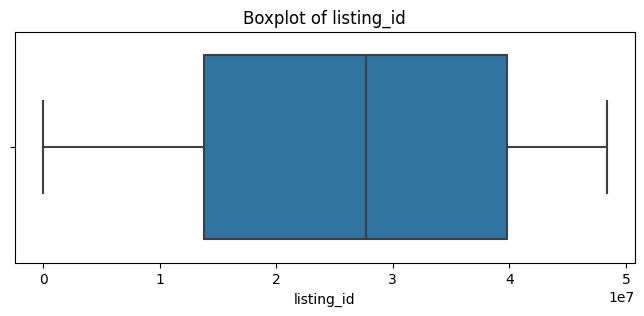

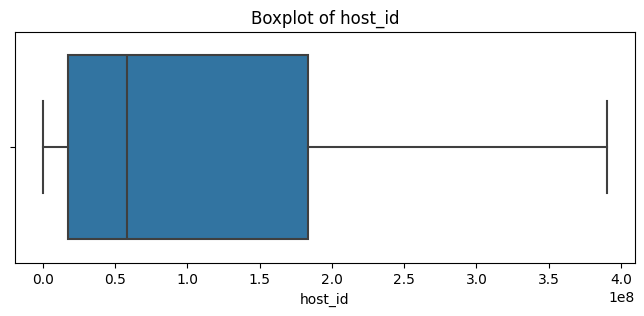

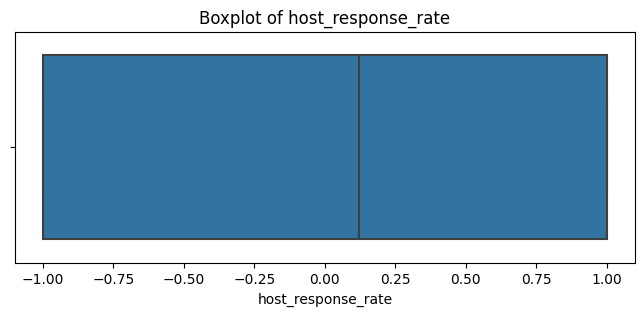

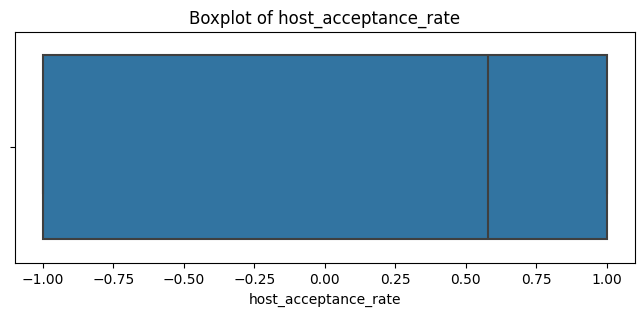

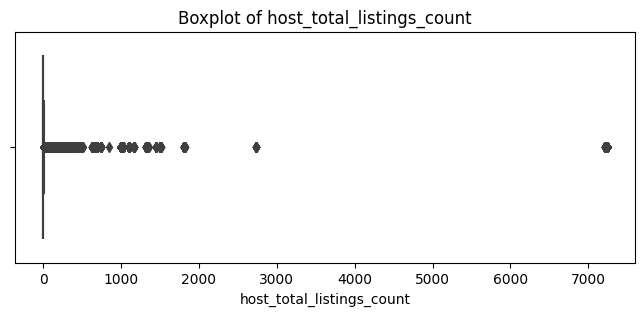

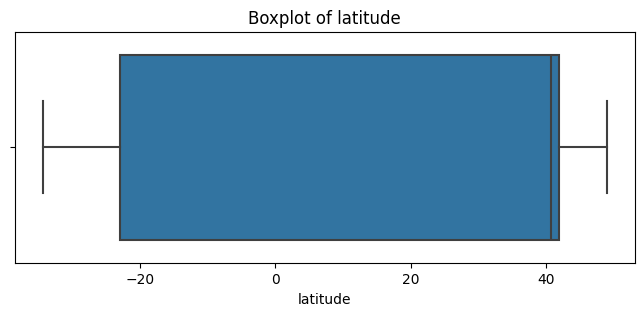

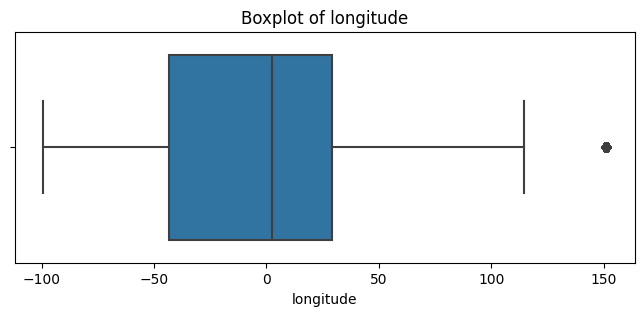

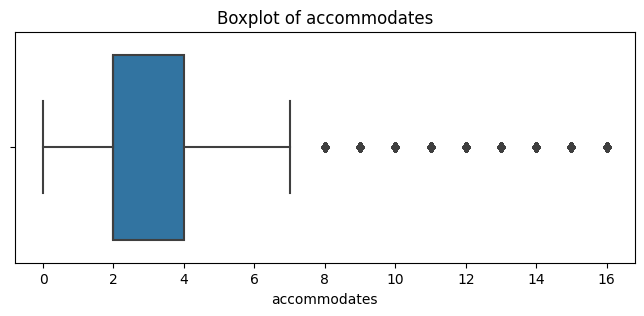

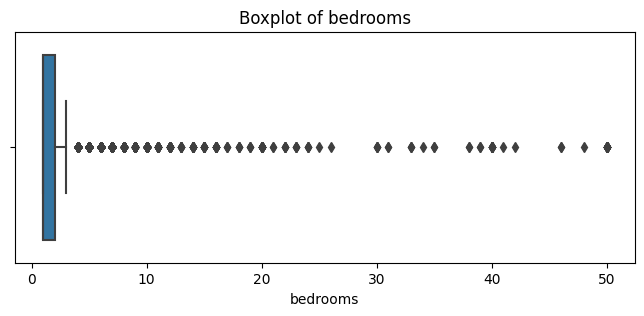

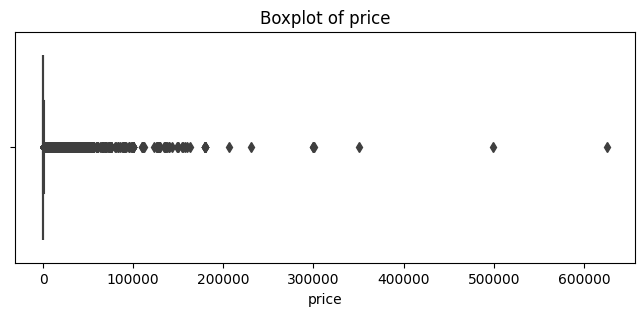

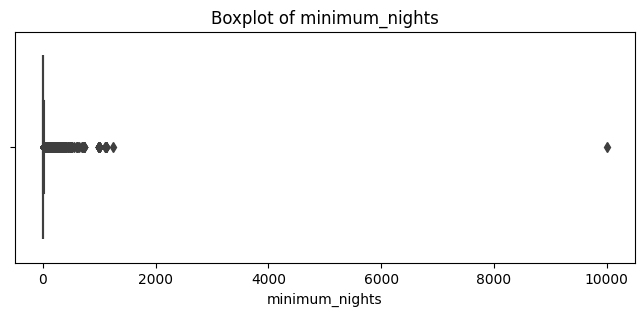

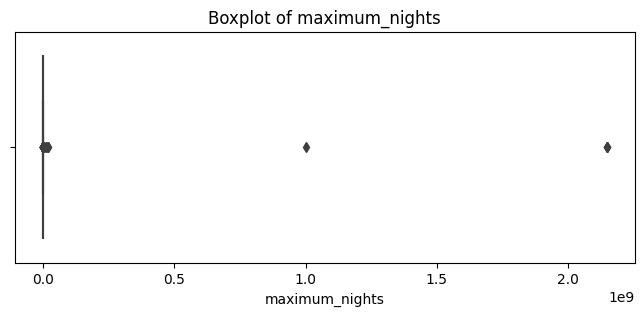

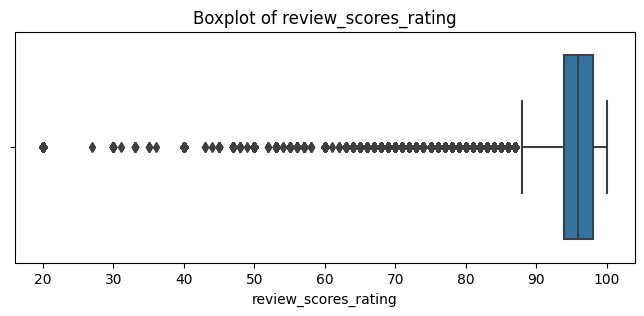

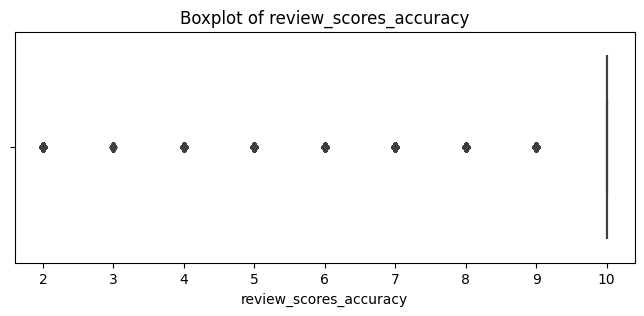

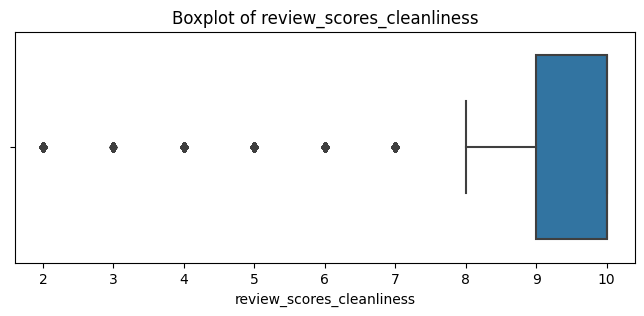

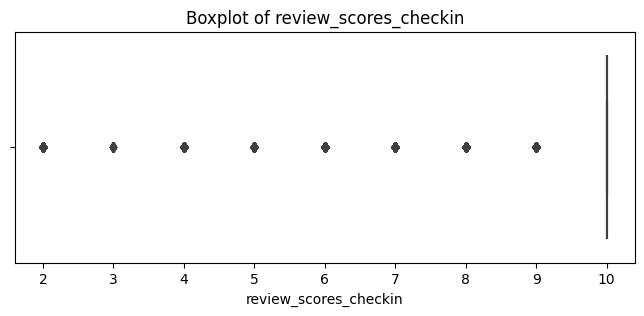

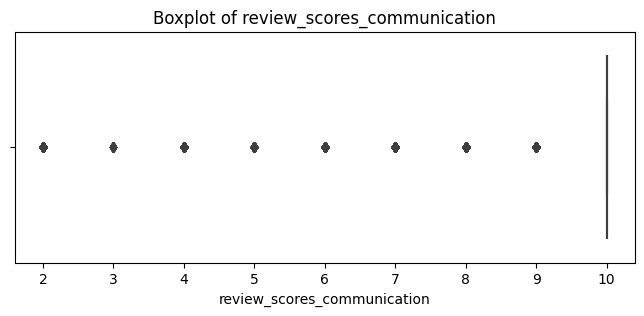

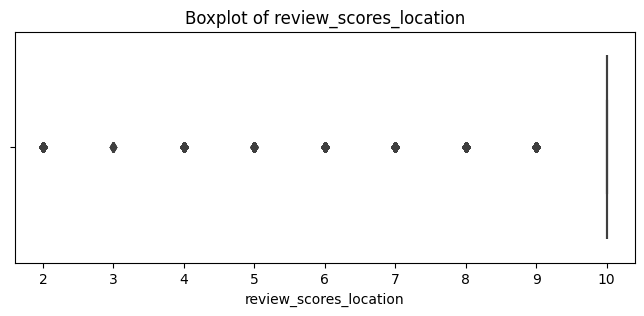

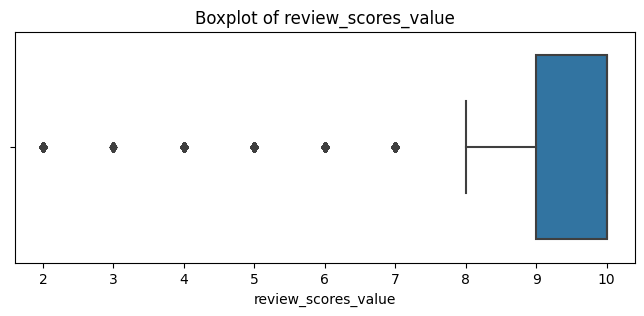

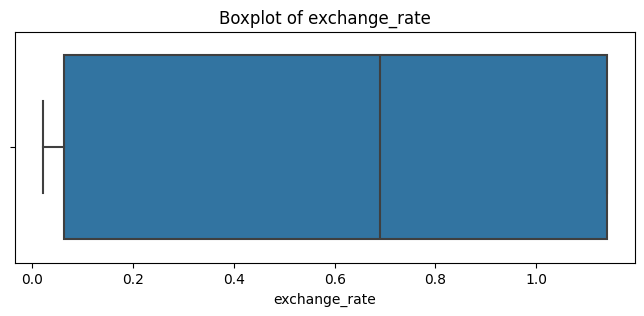

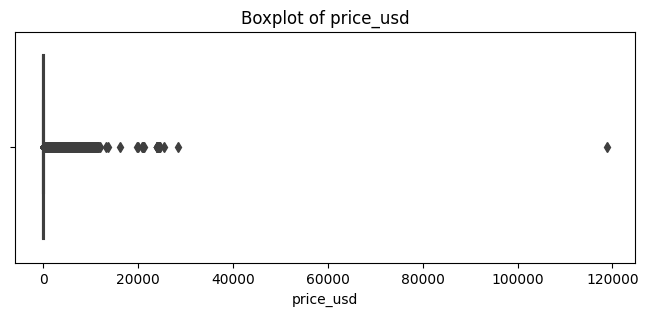

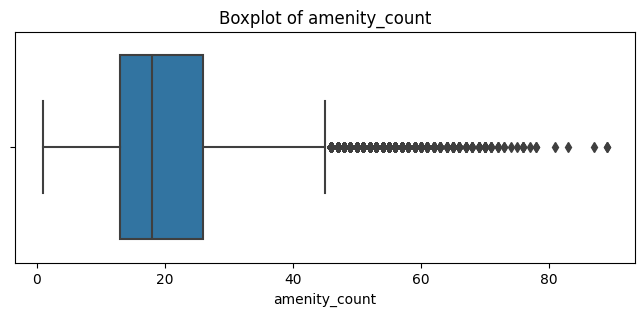

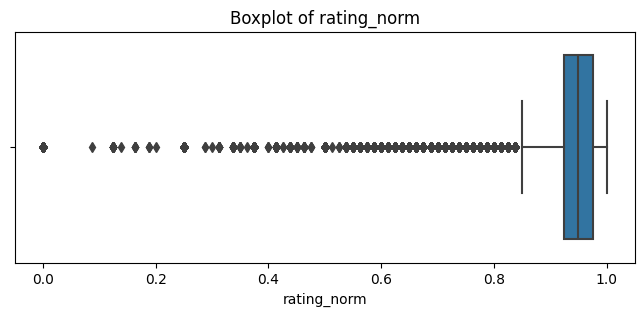

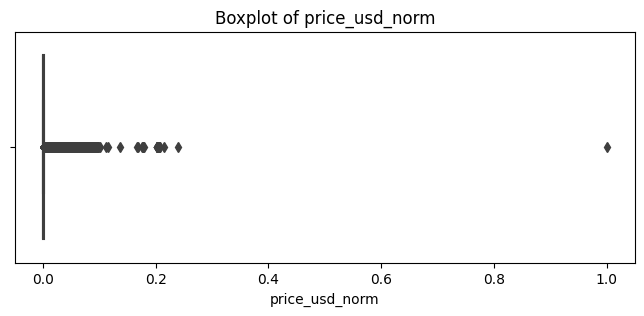

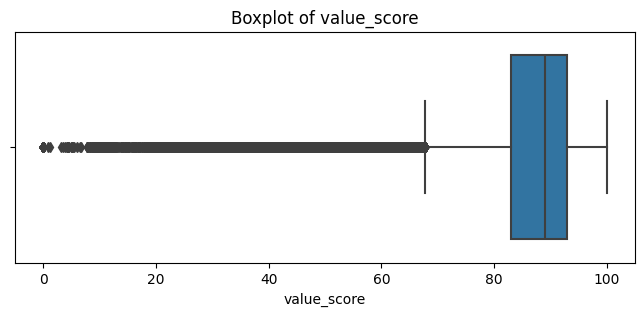

In [28]:
# Visualize outliers using boxplots
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=airbnb_proj[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [29]:
# Calculate outliers using the IQR method
for col in num_cols:

    Q1 = airbnb_proj[col].quantile(0.25)
    Q3 = airbnb_proj[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = airbnb_proj[
        (airbnb_proj[col] < lower) |
        (airbnb_proj[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

listing_id: 0 outliers
host_id: 0 outliers
host_response_rate: 0 outliers
host_acceptance_rate: 0 outliers
host_total_listings_count: 42065 outliers
latitude: 0 outliers
longitude: 33630 outliers
accommodates: 13607 outliers
bedrooms: 10207 outliers
price: 31395 outliers
minimum_nights: 43105 outliers
maximum_nights: 64 outliers
review_scores_rating: 28114 outliers
review_scores_accuracy: 51609 outliers
review_scores_cleanliness: 9763 outliers
review_scores_checkin: 34944 outliers
review_scores_communication: 34476 outliers
review_scores_location: 47442 outliers
review_scores_value: 7139 outliers
exchange_rate: 0 outliers
price_usd: 22783 outliers
amenity_count: 2566 outliers
rating_norm: 28114 outliers
price_usd_norm: 22783 outliers
value_score: 16133 outliers


In [30]:
# Calculate percentage of outliers
for col in num_cols:

    Q1 = airbnb_proj[col].quantile(0.25)
    Q3 = airbnb_proj[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        ((airbnb_proj[col] < lower) |
         (airbnb_proj[col] > upper))
    ).sum()

    percent = n_outliers / len(airbnb_proj) * 100

    print(f"{col:<30} {percent:.2f}%")

listing_id                     0.00%
host_id                        0.00%
host_response_rate             0.00%
host_acceptance_rate           0.00%
host_total_listings_count      15.04%
latitude                       0.00%
longitude                      12.02%
accommodates                   4.86%
bedrooms                       3.65%
price                          11.22%
minimum_nights                 15.41%
maximum_nights                 0.02%
review_scores_rating           10.05%
review_scores_accuracy         18.45%
review_scores_cleanliness      3.49%
review_scores_checkin          12.49%
review_scores_communication    12.33%
review_scores_location         16.96%
review_scores_value            2.55%
exchange_rate                  0.00%
price_usd                      8.15%
amenity_count                  0.92%
rating_norm                    10.05%
price_usd_norm                 8.15%
value_score                    5.77%


In [31]:
airbnb_proj[num_cols].skew().sort_values()

review_scores_checkin           -6.447810
review_scores_communication     -6.413806
review_scores_location          -5.274871
review_scores_accuracy          -5.158315
rating_norm                     -4.731378
review_scores_rating            -4.731378
review_scores_value             -3.895130
review_scores_cleanliness       -3.707899
value_score                     -3.088003
latitude                        -0.710930
host_acceptance_rate            -0.250485
listing_id                      -0.193098
exchange_rate                   -0.162503
host_response_rate              -0.050584
longitude                        0.490553
amenity_count                    0.724470
host_id                          0.955389
accommodates                     2.197609
bedrooms                        13.676402
host_total_listings_count       23.497029
price                           61.616178
price_usd_norm                 103.464029
price_usd                      103.464029
minimum_nights                 123

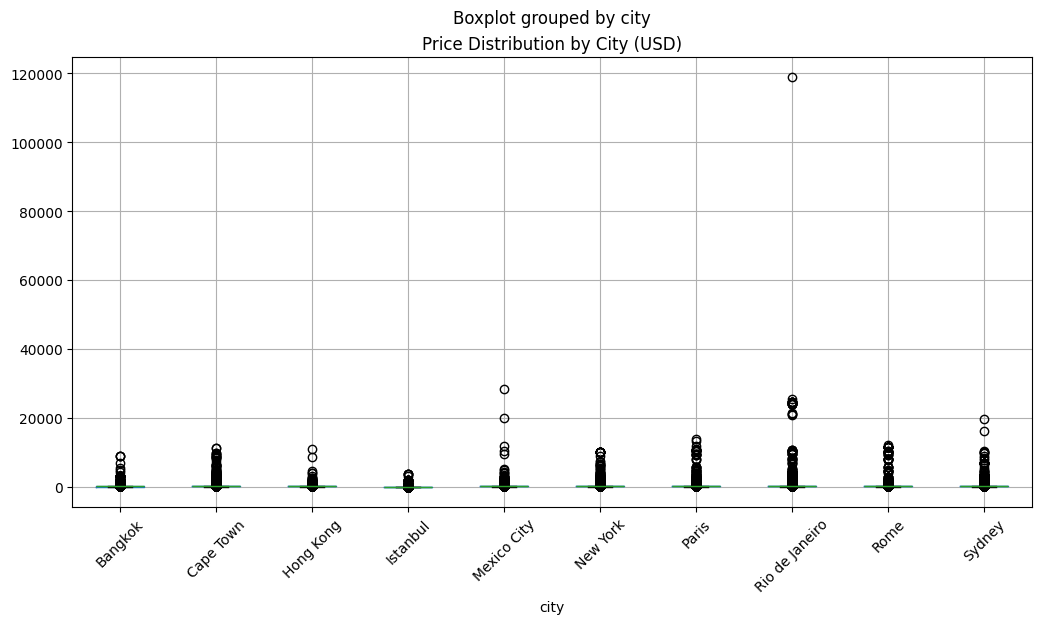

In [32]:
airbnb_proj.boxplot(column='price_usd', by='city', figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Price Distribution by City (USD)")
plt.show()

In [33]:
# Log transform price to reduce skewness
airbnb_proj['log_price'] = np.log1p(airbnb_proj['price_usd'])

In [34]:
# check the bedroom feature, there is no unrealistic number like 0 or -1. 
# and the large values like 50 bedrooms may be valid for hotels or large villas
# these variables are ok to keep

airbnb_proj['bedrooms'].describe()

airbnb_proj.nsmallest(10, 'bedrooms')[
    ['city', 'property_type', 'bedrooms', 'price_usd']
]

,city,property_type,bedrooms,price_usd
0,Paris,Entire apartment,1.0,60.42
1,Paris,Entire apartment,1.0,136.80
2,Paris,Entire apartment,1.0,101.46
3,Paris,Entire apartment,1.0,66.12
4,Paris,Entire apartment,1.0,68.40
5,Paris,Entire apartment,1.0,108.30
6,Paris,Entire apartment,1.0,91.20
7,Paris,Entire apartment,1.0,67.26
8,Paris,Entire apartment,1.0,91.20
9,Paris,Entire apartment,1.0,102.60


In [35]:
airbnb_proj['bedrooms'].describe()
airbnb_proj.nlargest(50, 'bedrooms')[
    ['city', 'property_type', 'bedrooms', 'price_usd']
]

,city,property_type,bedrooms,price_usd
44226,Mexico City,Entire apartment,50.0,206.00
91807,Istanbul,Private room in serviced apartment,50.0,4.49
92133,Mexico City,Room in bed and breakfast,50.0,104.42
95290,Istanbul,Room in hotel,50.0,10.94
96185,Mexico City,Room in hotel,50.0,34.20
96619,Mexico City,Room in serviced apartment,50.0,105.91
97284,Istanbul,Room in hotel,50.0,2.10
97285,Istanbul,Room in hotel,50.0,3.78
97294,Istanbul,Room in hotel,50.0,2.52
97365,Cape Town,Room in boutique hotel,50.0,186.00


In [36]:
# check the host_total_listings_count feature, the smallest values is 0 -> not an unrealistic value
# the largest values all belong to the same host_id, 
# it means that this host manages many Airbnb listings. 
# This is common for property management companies or commercial hosts.
# This is not an outlier caused by an error

airbnb_proj['host_total_listings_count'].describe()

airbnb_proj.nsmallest(10, 'host_total_listings_count')[
    ['host_id', 'host_total_listings_count']
]

,host_id,host_total_listings_count
36449,11716309,0.0
36458,273344288,0.0
36499,41821010,0.0
36510,12061757,0.0
36512,270629822,0.0
36514,105442120,0.0
36515,333828322,0.0
36535,9869763,0.0
36550,4389298,0.0
36551,6618901,0.0


In [37]:
airbnb_proj['host_total_listings_count'].describe()

airbnb_proj.nlargest(10, 'host_total_listings_count')[
    ['host_id', 'host_total_listings_count']
]

,host_id,host_total_listings_count
159638,175128252,7235.0
159639,175128252,7235.0
159665,175128252,7235.0
159667,175128252,7235.0
167765,175128252,7235.0
167766,175128252,7235.0
167767,175128252,7235.0
167768,175128252,7235.0
167769,175128252,7235.0
167770,175128252,7235.0


In [38]:
# check the Minimum and maximum nights features. 
# These variables are almost always heavily skewed because many listings allow bookings up to 365 or 1125 nights.
# There are not impossible values like -1,... and there is not meaningless values like 0 -> do not need to remove

airbnb_proj['minimum_nights'].value_counts().head(20)

minimum_nights
1      92839
2      60877
3      37869
30     28881
5      13770
4      12856
7      11356
6       3471
10      2810
14      2330
28      1894
15      1701
29      1118
90       937
20       888
60       724
31       656
8        504
21       453
180      443
Name: count, dtype: int64

In [39]:
airbnb_proj['maximum_nights'].value_counts().head(20)

maximum_nights
1125    157596
30       20449
365      15659
90        8165
60        6368
7         5244
15        5154
28        4344
14        4016
10        4000
180       3259
31        3191
20        2923
21        2346
120       2316
5         1928
29        1850
1124      1788
100       1458
6         1330
Name: count, dtype: int64

## 7. Data Type Conversion

In [40]:
airbnb_proj.nunique().sort_values()

instant_bookable                    2
host_is_superhost                   2
host_has_profile_pic                2
host_identity_verified              2
room_type                           4
host_response_time                  5
review_scores_location              9
review_scores_communication         9
review_scores_checkin               9
review_scores_cleanliness           9
review_scores_accuracy              9
exchange_rate                       9
review_scores_value                 9
city                               10
host_years                         14
accommodates                       17
bedrooms                           39
review_scores_rating               63
rating_norm                        63
amenity_count                      82
host_response_rate                 92
host_acceptance_rate              102
property_type                     144
minimum_nights                    202
host_total_listings_count         206
maximum_nights                    508
neighbourhoo

In [41]:
airbnb_proj = pd.get_dummies(data=airbnb_proj, columns = ['host_is_superhost', 'host_has_profile_pic', 
                                                          'host_identity_verified','instant_bookable'], 
                             dtype=int)

In [42]:
list(airbnb_proj.columns)

['listing_id',
 'name',
 'host_id',
 'host_since',
 'host_location',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_total_listings_count',
 'neighbourhood',
 'city',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bedrooms',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'exchange_rate',
 'price_usd',
 'amenity_count',
 'host_years',
 'rating_norm',
 'price_usd_norm',
 'value_score',
 'log_price',
 'host_is_superhost_f',
 'host_is_superhost_t',
 'host_has_profile_pic_f',
 'host_has_profile_pic_t',
 'host_identity_verified_f',
 'host_identity_verified_t',
 'instant_bookable_f',
 'instant_bookable_t']

## 8. Export data

In [43]:
airbnb_proj.to_csv(
    "airbnb_cleaned.csv",
    index=False
)

# **Reviews dataset**

## 1. Import Data

In [44]:
# Load Airbnb reviews dataset
reviews = pd.read_csv(
    "Reviews.csv",
    encoding='latin1',
    low_memory=False,
    on_bad_lines='skip'
)

In [45]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   listing_id   int64 
 1   review_id    int64 
 2   date         object
 3   reviewer_id  int64 
dtypes: int64(3), object(1)
memory usage: 164.0+ MB


## 2. Detect and handle duplicates

In [46]:
dups_rows_reviews = reviews.duplicated() #view the duplicated rows for reviews file
dups_rows_reviews

0          False
1          False
2          False
3          False
4          False
           ...  
5373138    False
5373139    False
5373140    False
5373141    False
5373142    False
Length: 5373143, dtype: bool

In [47]:
dups_rows_reviews.sum()  

0

In [48]:
dup_col_reviews = reviews.columns.duplicated()      #View the duplicated column
duplicate_columns_reviews = reviews.columns[dup_col_reviews]
print(duplicate_columns_reviews)

Index([], dtype='object')


In [49]:
unique_value_counts_reviews = reviews.nunique()     #count the number of unique value in each column
unique_value_counts_reviews

listing_id      193556
review_id      5372983
date              4103
reviewer_id    4450005
dtype: int64

## 3. Detect and handle missing values

In [50]:
m_dict_reviews = missing(reviews)
print ('\nMissing data in reviews dataset\n')
m_dict_reviews


Missing data in reviews dataset



{'listing_id': 0.0, 'review_id': 0.0, 'date': 0.0, 'reviewer_id': 0.0}

In [51]:
neighbourhood_city_check = (
    airbnb_proj
    .groupby('neighbourhood')['city']
    .nunique()
    .sort_values(ascending=False)
)

neighbourhood_city_check.head(50)

neighbourhood
Abolicao                1
Santa Teresa            1
Santo Cristo            1
Sao Conrado             1
Sao Cristovao           1
Sao Francisco Xavier    1
Saphan Sung             1
Sariyer                 1
Sathon                  1
Saude                   1
Schuylerville           1
Sea Gate                1
Senador Camara          1
Senador Vasconcelos     1
Sepetiba                1
Sha Tin                 1
Sham Shui Po            1
Sheepshead Bay          1
Shore Acres             1
Santissimo              1
Santa Cruz              1
Richmond Hill           1
Sancaktepe              1
Ridgewood               1
Rio Comprido            1
Riverdale               1
Rocha                   1
Rocha Miranda           1
Rocinha                 1
Rockaway Beach          1
Rockdale                1
Roosevelt Island        1
Rosebank                1
Rosedale                1
Rossville               1
Ryde                    1
Sai Kung                1
Sai Mai                 

## 4. Data Type Conversion

In [52]:
# Convert date and create year/month

reviews['date'] = pd.to_datetime(reviews['date'])

reviews['year'] = reviews['date'].dt.year
reviews['month'] = reviews['date'].dt.month

In [53]:
reviews[['date','year','month']].head()

,date,year,month
0,2018-09-30,2018,9
1,2018-09-30,2018,9
2,2018-09-30,2018,9
3,2018-09-30,2018,9
4,2018-09-30,2018,9


## 5. Create Relationship between 2 datasets

In [54]:
# Merge reviews with listing information
reviews_city = reviews.merge(
    airbnb_proj[['listing_id','city','neighbourhood']],
    on='listing_id',
    how='left'
)

In [66]:
reviews.head()

,listing_id,review_id,date,reviewer_id,year,month
0,11798,330265172,2018-09-30,11863072,2018,9
1,15383,330103585,2018-09-30,39147453,2018,9
2,16455,329985788,2018-09-30,1125378,2018,9
3,17919,330016899,2018-09-30,172717984,2018,9
4,26827,329995638,2018-09-30,17542859,2018,9


## 6. Feature Creation and Data Aggregation

In [56]:
# Monthly demand by neighbourhood

review_neighbourhood = (
    reviews_city
    .groupby(
        ['city', 'neighbourhood', 'year', 'month']
    )
    .size()
    .reset_index(name='review_count_neighbourhood')
)

In [60]:
# Monthly demand by city

review_city = (
    reviews_city
    .groupby(
        ['city', 'year', 'month']
    )
    .size()
    .reset_index(name='review_count_city')
)

In [61]:
# Total reviews by neighbourhood

neighbourhood_summary = (
    reviews_city
    .groupby(
        ['city', 'neighbourhood']
    )
    .size()
    .reset_index(name='total_reviews_neighbourhood')
)

In [62]:
# combine neighbourhood monthly demand with city monthly demand

monthly_demand = review_neighbourhood.merge(
    review_city,
    on=['city', 'year', 'month'],
    how='left'
)

In [63]:
# add total neighbourhood demand

monthly_demand = monthly_demand.merge(
    neighbourhood_summary,
    on=['city', 'neighbourhood'],
    how='left'
)

In [64]:
# Create date column

monthly_demand['date'] = pd.to_datetime(
    monthly_demand['year'].astype(str)
    + '-'
    + monthly_demand['month'].astype(str)
    + '-01'
)

In [65]:
# Arrange columns

monthly_demand = monthly_demand[
    [
        'city',
        'neighbourhood',
        'year',
        'month',
        'date',
        'review_count_neighbourhood',
        'review_count_city',
        'total_reviews_neighbourhood'
    ]
]

## 7. Export data

In [67]:
monthly_demand.to_csv(
    "airbnb_demand.csv",
    index=False
)

In [68]:
neighbourhood_summary.to_csv(
    "neighbourhood_summary.csv",
    index=False
)

In [69]:
city_table = monthly_demand[['city']].drop_duplicates()

In [70]:
city_table.to_csv(
    "city_table.csv",
    index=False
)